In [3]:
import os
print(os.getcwd())

/Users/hazaraking/Desktop/human cognition 2


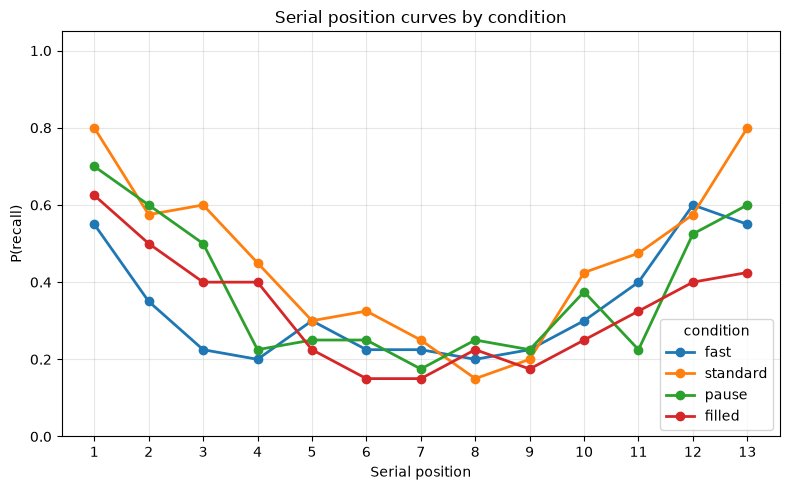

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("freerecall_main_hypothetical2.csv")

# mean P(recall) at each serial position, per condition
curve = df.pivot_table(index="serial_position",
                       columns="condition",
                       values="recalled",
                       aggfunc="mean")

order = ["fast", "standard", "pause", "filled"]        # controls legend/line order
curve = curve[[c for c in order if c in curve.columns]]

plt.figure(figsize=(8, 5))
for cond in curve.columns:
    plt.plot(curve.index, curve[cond], marker="o", linewidth=2, label=cond)

plt.xlabel("Serial position")
plt.ylabel("P(recall)")
plt.title("Serial position curves by condition")
plt.xticks(range(int(curve.index.min()), int(curve.index.max()) + 1))
plt.ylim(0, 1.05)
plt.legend(title="condition")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("serial_position.png", dpi=120)   # remove if you only want to view
plt.show()

In [13]:
import pandas as pd

b = pd.read_csv("freerecall_main_hypothetical2.csv")
b = b.iloc[:, :-1]                       # drop the last column
b.to_csv("freerecall_main_marcus.csv", index=False)
print("done — columns now:", b.columns.tolist())

done — columns now: ['participant', 'run', 'timestamp', 'trial', 'condition', 'rate_s', 'delay_s', 'serial_position', 'item']


In [14]:
df.participant.value_counts()

participant
Asghar    1040
Marcus    1040
Name: count, dtype: int64

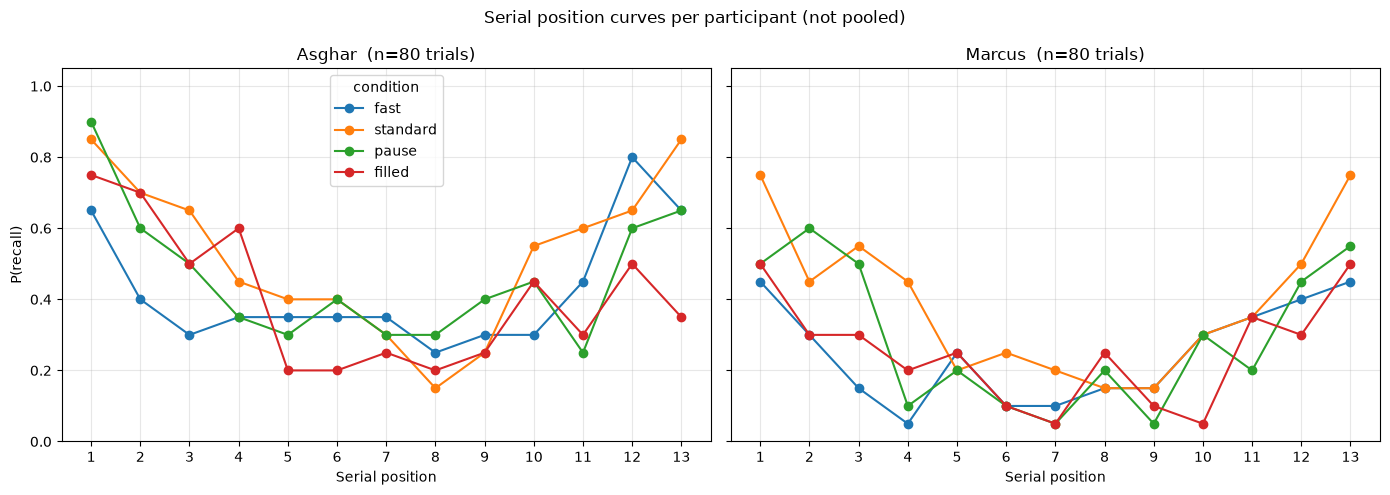

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("freerecall_main_hypothetical2.csv")   # your merged file

order = ["fast", "standard", "pause", "filled"]
participants = sorted(df.participant.unique())

fig, axes = plt.subplots(1, len(participants), figsize=(7 * len(participants), 5),
                         sharey=True)
if len(participants) == 1:
    axes = [axes]

for ax, person in zip(axes, participants):
    sub = df[df.participant == person]
    curve = sub.pivot_table(index="serial_position", columns="condition",
                            values="recalled", aggfunc="mean")
    curve = curve[[c for c in order if c in curve.columns]]
    for cond in curve.columns:
        ax.plot(curve.index, curve[cond], marker="o", label=cond)
    n_trials = sub[["run", "trial"]].drop_duplicates().shape[0]
    ax.set_title(f"{person}  (n={n_trials} trials)")
    ax.set_xlabel("Serial position")
    ax.set_xticks(range(1, 14))
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("P(recall)")
axes[0].legend(title="condition")
plt.suptitle("Serial position curves per participant (not pooled)")
plt.tight_layout()
plt.savefig("serial_position_by_participant.png", dpi=120)
plt.show()

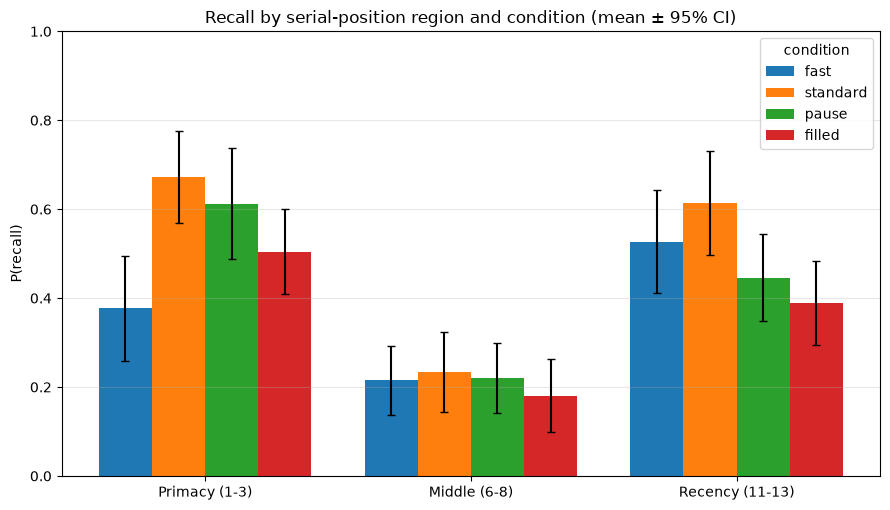

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("freerecall_main_hypothetical2.csv")   # <-- your pooled file

# --- assign each serial position to a region (notes' baseline = middle 6-8) ---
def region(pos):
    if pos <= 3:  return "Primacy (1-3)"
    if pos >= 11: return "Recency (11-13)"
    if 6 <= pos <= 8: return "Middle (6-8)"
    return None                      # positions 4-5 and 9-10 excluded from regions

df = df.copy()
df["region"] = df["serial_position"].apply(region)
reg = df.dropna(subset=["region"])

# --- per-trial region score, then mean +/- 95% CI across trials ---
trial = (reg.groupby(["condition", "region", "run", "trial"])
            .recalled.mean().reset_index())

def mean_ci(x):
    x = np.asarray(x, float); n = len(x)
    h = stats.t.ppf(0.975, n-1) * x.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    return x.mean(), h

regions    = ["Primacy (1-3)", "Middle (6-8)", "Recency (11-13)"]
conditions = ["fast", "standard", "pause", "filled"]
colors     = {"fast":"#1f77b4", "standard":"#ff7f0e",
              "pause":"#2ca02c", "filled":"#d62728"}

fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(regions)); w = 0.2

for i, cond in enumerate(conditions):
    means, errs = [], []
    for r in regions:
        vals = trial[(trial.condition == cond) & (trial.region == r)].recalled
        m, h = mean_ci(vals); means.append(m); errs.append(h)
    ax.bar(x + (i - 1.5)*w, means, w, yerr=errs, capsize=3,
           label=cond, color=colors[cond])

ax.set_xticks(x); ax.set_xticklabels(regions)
ax.set_ylabel("P(recall)")
ax.set_title("Recall by serial-position region and condition (mean ± 95% CI)")
ax.set_ylim(0, 1); ax.legend(title="condition"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("region_quantification.png", dpi=120)
plt.show()

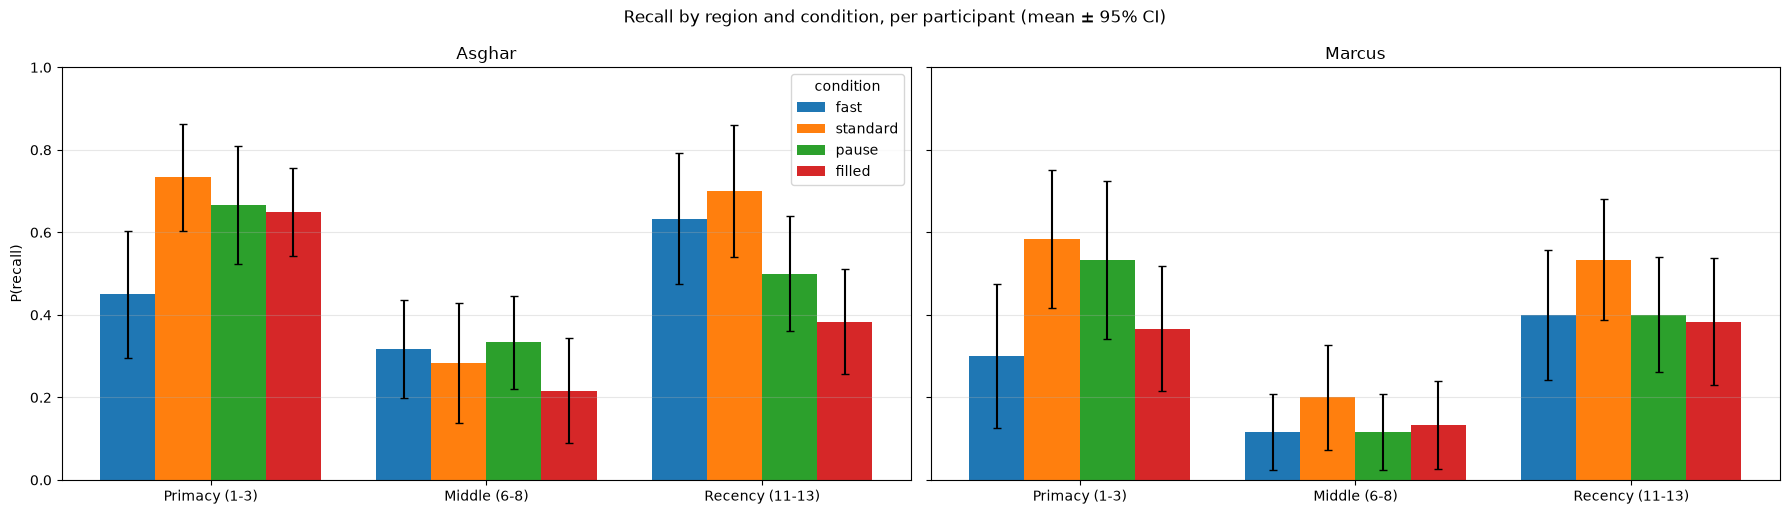

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("freerecall_main_hypothetical2.csv")   # <-- file that has BOTH participants

def region(pos):
    if pos <= 3:  return "Primacy (1-3)"
    if pos >= 11: return "Recency (11-13)"
    if 6 <= pos <= 8: return "Middle (6-8)"
    return None

df = df.copy()
df["region"] = df["serial_position"].apply(region)
reg = df.dropna(subset=["region"])

# per-trial region score
trial = (reg.groupby(["participant", "condition", "region", "run", "trial"])
            .recalled.mean().reset_index())

def mean_ci(x):
    x = np.asarray(x, float); n = len(x)
    h = stats.t.ppf(0.975, n-1) * x.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    return x.mean(), h

regions    = ["Primacy (1-3)", "Middle (6-8)", "Recency (11-13)"]
conditions = ["fast", "standard", "pause", "filled"]
colors     = {"fast":"#1f77b4", "standard":"#ff7f0e",
              "pause":"#2ca02c", "filled":"#d62728"}
people = sorted(df.participant.unique())

fig, axes = plt.subplots(1, len(people), figsize=(9*len(people), 5.2), sharey=True)
if len(people) == 1:
    axes = [axes]

x = np.arange(len(regions)); w = 0.2
for ax, person in zip(axes, people):
    sub = trial[trial.participant == person]
    for i, cond in enumerate(conditions):
        means, errs = [], []
        for r in regions:
            vals = sub[(sub.condition == cond) & (sub.region == r)].recalled
            m, h = mean_ci(vals); means.append(m); errs.append(h)
        ax.bar(x + (i-1.5)*w, means, w, yerr=errs, capsize=3,
               label=cond, color=colors[cond])
    ax.set_xticks(x); ax.set_xticklabels(regions)
    ax.set_title(person); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("P(recall)")
axes[0].legend(title="condition")
plt.suptitle("Recall by region and condition, per participant (mean ± 95% CI)")
plt.tight_layout()
plt.savefig("region_quantification_by_participant.png", dpi=120)
plt.show()

In [19]:
import pandas as pd, numpy as np
from scipy import stats

df = pd.read_csv("freerecall_main_hypothetical2.csv")   # <-- your real merged file

def region(p):
    if p <= 3:        return "Primacy (1-3)"
    if 6 <= p <= 8:   return "Middle (6-8)"
    if p >= 11:       return "Recency (11-13)"
    return None

df = df.copy()
df["region"] = df["serial_position"].apply(region)
reg = df.dropna(subset=["region"])

# per-trial region score, then mean +/- 95% CI across trials
trial = (reg.groupby(["region", "condition", "run", "trial"])
            .recalled.mean().reset_index())

def mean_ci(x):
    x = np.asarray(x, float); n = len(x)
    h = stats.t.ppf(0.975, n-1) * x.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    return x.mean(), h

for reg_name in ["Primacy (1-3)", "Middle (6-8)", "Recency (11-13)"]:
    print(f"\n{reg_name}")
    for cond in ["fast", "standard", "pause", "filled"]:
        x = trial[(trial.region == reg_name) & (trial.condition == cond)].recalled
        if len(x) == 0:
            print(f"  {cond:9s}  (no data)"); continue
        m, h = mean_ci(x)
        print(f"  {cond:9s}  mean={m:.3f}  95% CI=[{m-h:.3f}, {m+h:.3f}]  (n={len(x)} trials)")


Primacy (1-3)
  fast       mean=0.377  95% CI=[0.259, 0.495]  (n=38 trials)
  standard   mean=0.671  95% CI=[0.568, 0.775]  (n=35 trials)
  pause      mean=0.613  95% CI=[0.488, 0.737]  (n=34 trials)
  filled     mean=0.505  95% CI=[0.409, 0.600]  (n=36 trials)

Middle (6-8)
  fast       mean=0.215  95% CI=[0.138, 0.292]  (n=38 trials)
  standard   mean=0.233  95% CI=[0.143, 0.324]  (n=35 trials)
  pause      mean=0.221  95% CI=[0.141, 0.300]  (n=34 trials)
  filled     mean=0.181  95% CI=[0.098, 0.263]  (n=36 trials)

Recency (11-13)
  fast       mean=0.526  95% CI=[0.411, 0.642]  (n=38 trials)
  standard   mean=0.614  95% CI=[0.497, 0.731]  (n=35 trials)
  pause      mean=0.446  95% CI=[0.348, 0.544]  (n=34 trials)
  filled     mean=0.389  95% CI=[0.295, 0.483]  (n=36 trials)
